<a href="https://colab.research.google.com/github/wongsiulam/-/blob/main/P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module A - Data & Preprocessing

This module prepares the dataset, builds `labels.csv`, configures augmentations, visualizes samples, and validates `DataLoader` outputs.

- Dataset source: HEp-2 cell images (provided in `Datasets/`)
- Splits: training / validation / test as provided
- Augmentations: random resized crop, horizontal/vertical flip, normalization
- Outputs: `labels.csv`, augmentation report images, and ready-to-use `dataset.py`


In [2]:
# Imports and paths
import os
import csv
import random
from typing import List, Dict

import torch
import torchvision
from torchvision import transforms as T
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

# Inline implementation in this notebook
try:
    PROJECT_ROOT = os.path.abspath(os.path.dirname(__file__))
except NameError:
    PROJECT_ROOT = os.getcwd()
DATASETS_DIR = os.path.join(PROJECT_ROOT, 'Datasets')
GT_TRAIN_CSV = os.path.join(PROJECT_ROOT, 'gt_training.csv')
LABELS_CSV = os.path.join(PROJECT_ROOT, 'labels.csv')

print('Project root:', PROJECT_ROOT)
print('Datasets dir:', DATASETS_DIR)
print('GT CSV exists:', os.path.exists(GT_TRAIN_CSV))


Project root: /content
Datasets dir: /content/Datasets
GT CSV exists: True


In [3]:
# Dataset utilities
from typing import Optional, Tuple, Callable


def _read_gt_csv(gt_csv_path: str) -> Dict[int, str]:
    """Read ground-truth mapping: image_id -> class name."""
    id_to_class: Dict[int, str] = {}
    with open(gt_csv_path, 'r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            image_id_raw = row.get('Image ID') or row.get('Image_ID') or row.get('image_id')
            image_class = row.get('Image class') or row.get('Image_class') or row.get('class')
            if image_id_raw is None or image_class is None:
                continue
            try:
                image_id = int(str(image_id_raw).strip())
            except ValueError:
                continue
            id_to_class[image_id] = str(image_class).strip()
    return id_to_class


def build_labels_csv_from_gt(gt_csv_path: str, out_csv_path: str) -> str:
    """
    Build a unified labels.csv using training split files and global GT CSV.
    Output schema: filename,label (filename like '00001.png').
    """
    os.makedirs(os.path.dirname(out_csv_path), exist_ok=True)

    id_to_class = _read_gt_csv(gt_csv_path)
    train_dir = os.path.join(DATASETS_DIR, 'training')
    assert os.path.isdir(train_dir), f'Missing training directory: {train_dir}'

    image_filenames = [fn for fn in os.listdir(train_dir) if fn.lower().endswith(('.png', '.jpg', '.jpeg'))]
    image_filenames.sort()

    with open(out_csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['filename', 'label'])
        for fn in image_filenames:
            stem = os.path.splitext(fn)[0]
            try:
                image_id = int(stem.lstrip('0') or '0')
            except ValueError:
                continue
            lbl = id_to_class.get(image_id)
            if lbl is None:
                continue
            writer.writerow([fn, lbl])

    return out_csv_path


def load_label_map(labels_csv_path: str) -> Tuple[Dict[str, int], List[str]]:
    """Load class names from labels.csv and return (class_to_index, index_to_class)."""
    classes: List[str] = []
    with open(labels_csv_path, 'r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            lbl = (row.get('label') or '').strip()
            if lbl and lbl not in classes:
                classes.append(lbl)
    classes.sort()
    class_to_index = {c: i for i, c in enumerate(classes)}
    return class_to_index, classes


class ImageDataset(torch.utils.data.Dataset):
    """
    Flat directory dataset with optional labels.csv. If a file is not present in
    labels.csv, its label is set to -1.
    """
    def __init__(
        self,
        root_dir: str,
        split: str,
        labels_csv_path: str,
        image_size: int = 224,
        random_crop_scale: Tuple[float, float] = (0.8, 1.0),
        random_hflip_prob: float = 0.5,
        random_vflip_prob: float = 0.0,
        is_train: bool = True,
    ) -> None:
        self.root_dir = root_dir
        self.split = split
        self.split_dir = os.path.join(root_dir, 'Datasets', split)
        assert os.path.isdir(self.split_dir), f'Missing split dir: {self.split_dir}'

        self.class_to_index, self.index_to_class = load_label_map(labels_csv_path) if os.path.exists(labels_csv_path) else ({}, [])

        # filename -> class string
        filename_to_label: Dict[str, str] = {}
        if os.path.exists(labels_csv_path):
            with open(labels_csv_path, 'r', newline='') as f:
                reader = csv.DictReader(f)
                for row in reader:
                    fn = (row.get('filename') or '').strip()
                    lbl = (row.get('label') or '').strip()
                    if fn:
                        filename_to_label[fn] = lbl

        # Files in this split
        image_filenames = [fn for fn in os.listdir(self.split_dir) if fn.lower().endswith(('.png', '.jpg', '.jpeg'))]
        image_filenames.sort()

        # Build sample list (path, label_index)
        self.samples: List[Tuple[str, int]] = []
        for fn in image_filenames:
            p = os.path.join(self.split_dir, fn)
            lbl = filename_to_label.get(fn)
            if lbl and lbl in self.class_to_index:
                idx = self.class_to_index[lbl]
            else:
                idx = -1
            self.samples.append((p, idx))

        # Transforms
        if is_train:
            self.transform: Callable = T.Compose([
                T.RandomResizedCrop(image_size, scale=random_crop_scale),
                T.RandomHorizontalFlip(p=random_hflip_prob),
                T.RandomVerticalFlip(p=random_vflip_prob),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        else:
            self.transform = T.Compose([
                T.Resize(int(image_size * 1.14)),
                T.CenterCrop(image_size),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        path, label_index = self.samples[index]
        with Image.open(path) as img:
            img = img.convert('RGB')
        img = self.transform(img)
        return img, label_index


def create_dataloader(dataset: torch.utils.data.Dataset, batch_size: int = 32, shuffle: bool = True, num_workers: int = 4) -> DataLoader:
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, pin_memory=True)



## Dataset source and splits

- Source: Provided HEp-2 cell dataset in `Datasets/` with three folders: `training/`, `validation/`, `test/`.
- We follow the given split directories. No reshuffling is applied.
- We build `labels.csv` from `gt_training.csv` mapping numeric image IDs to class names.


In [4]:
# Build labels.csv if missing
if not os.path.exists(LABELS_CSV):
    assert os.path.exists(GT_TRAIN_CSV), 'gt_training.csv not found'
    build_labels_csv_from_gt(GT_TRAIN_CSV, LABELS_CSV)

# Inspect first few rows
with open(LABELS_CSV, 'r') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 5:
            break


filename,label
00001.png,Homogeneous
00002.png,Homogeneous
00004.png,Homogeneous
00005.png,Homogeneous
00007.png,Homogeneous


## Augmentation strategy

- RandomResizedCrop to size 224 with scale (0.8, 1.0)
- RandomHorizontalFlip p=0.5
- Optional RandomVerticalFlip p=0.0 (can be increased if domain allows)
- Normalize to ImageNet mean/std


In [5]:
# Instantiate datasets and loaders

train_ds = ImageDataset(
    root_dir=PROJECT_ROOT,
    split='training',
    labels_csv_path=LABELS_CSV,
    image_size=224,
    random_crop_scale=(0.8, 1.0),
    random_hflip_prob=0.5,
    random_vflip_prob=0.0,
    is_train=True,
)
val_ds = ImageDataset(
    root_dir=PROJECT_ROOT,
    split='validation',
    labels_csv_path=LABELS_CSV,
    image_size=224,
    is_train=False,
)
test_ds = ImageDataset(
    root_dir=PROJECT_ROOT,
    split='test',
    labels_csv_path=LABELS_CSV,  # labels may be missing for test; handled as -1
    image_size=224,
    is_train=False,
)

train_loader = create_dataloader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = create_dataloader(val_ds, batch_size=32, shuffle=False, num_workers=4)
test_loader = create_dataloader(test_ds, batch_size=32, shuffle=False, num_workers=4)

print('Dataset sizes -> train:', len(train_ds), 'val:', len(val_ds), 'test:', len(test_ds))


Dataset sizes -> train: 8701 val: 2175 test: 2720


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Visualization of augmented samples

We visualize a few samples after applying train-time augmentations to ensure they look reasonable.


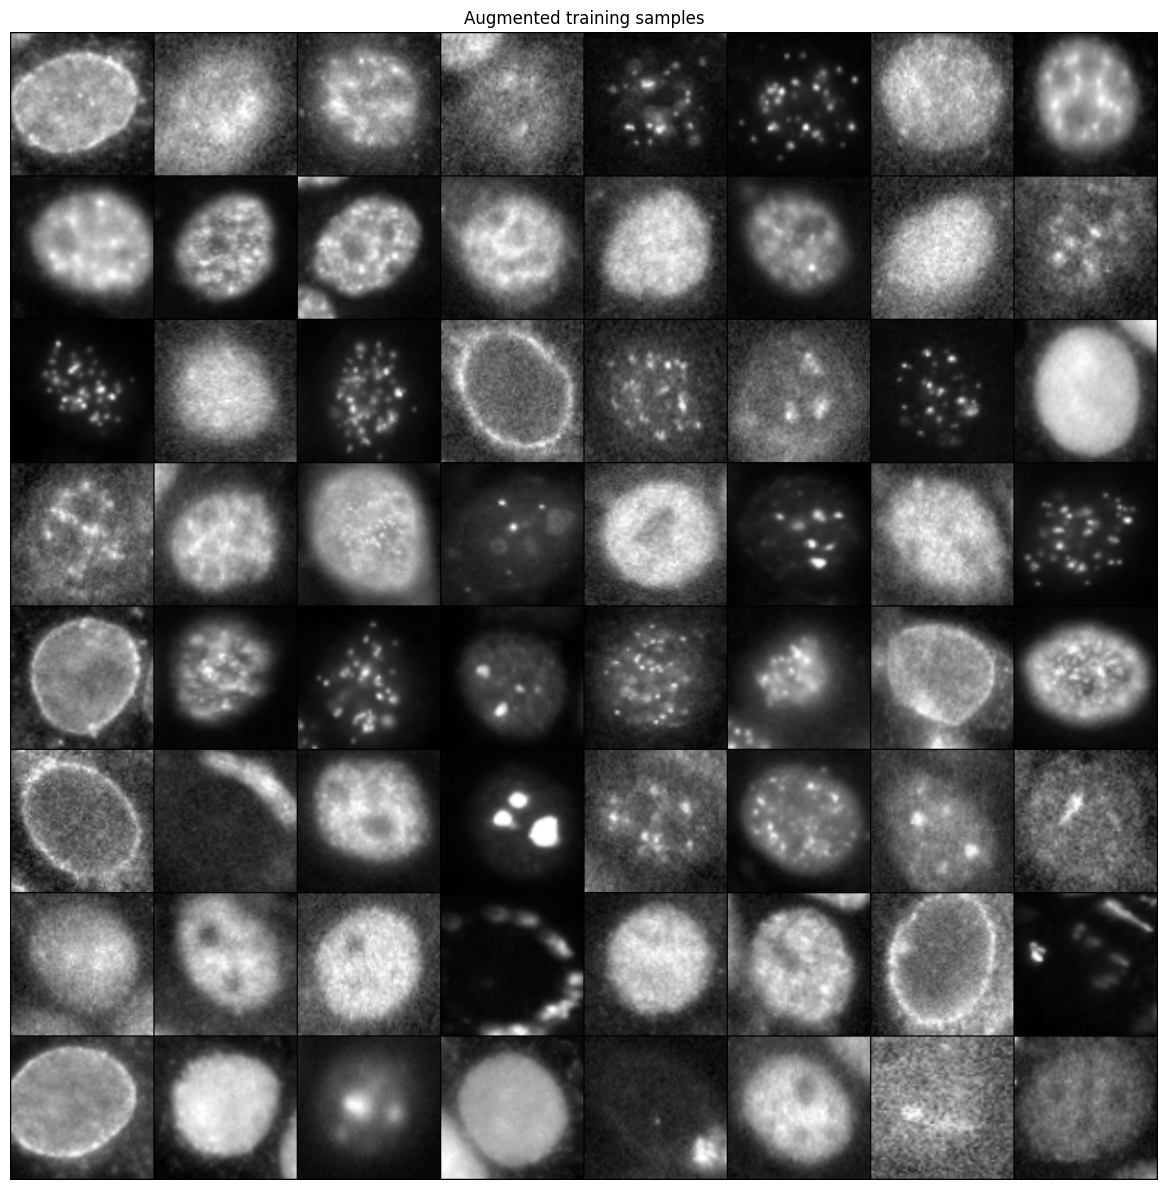

Saved augmentation report to: /content/augmentation_report.png


In [6]:
# Visualize N batches from train_loader and save a report image
import math
import torchvision.utils as vutils

N_BATCHES = 2
SAVE_PATH = os.path.join(PROJECT_ROOT, 'augmentation_report.png')

all_images = []
all_labels = []

for i, (images, labels) in enumerate(train_loader):
    all_images.append(images)
    all_labels.append(labels)
    if i + 1 >= N_BATCHES:
        break

images_cat = torch.cat(all_images, dim=0)[:64]  # at most 64 images for grid
labels_cat = torch.cat(all_labels, dim=0)[:64]

# Unnormalize for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
vis = images_cat * std + mean
vis = torch.clamp(vis, 0, 1)

grid = vutils.make_grid(vis, nrow=8)
plt.figure(figsize=(12,12))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title('Augmented training samples')
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=150)
plt.show()

print('Saved augmentation report to:', SAVE_PATH)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Validate DataLoader outputs

We check that `(images, labels)` have the expected shapes and types and are compatible with the model input.


In [7]:
# Check one batch
batch_images, batch_labels = next(iter(train_loader))
print('Batch images:', type(batch_images), batch_images.shape, batch_images.dtype)
print('Batch labels:', type(batch_labels), batch_labels.shape, batch_labels.dtype)

assert batch_images.ndim == 4 and batch_images.shape[1] == 3, 'Expect NCHW tensors with 3 channels'
assert batch_labels.ndim == 1, 'Labels should be 1D tensor'

print('DataLoader output is valid for model input.')


Batch images: <class 'torch.Tensor'> torch.Size([32, 3, 224, 224]) torch.float32
Batch labels: <class 'torch.Tensor'> torch.Size([32]) torch.int64
DataLoader output is valid for model input.


In [1]:
# 这一步用于解压文件
import zipfile
import os

zip_path = '/Datasets.zip'  # 替换为你的 ZIP 文件路径
extract_dir = '/content/'            # 解压到的目录

# 若解压目录不存在，创建之
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print('解压完成')

解压完成


**以下将开始模型的训练**

In [11]:
import torch
import torch.nn as nn  # 神经网络模块
import torch.optim as optim  # 优化器
import torchvision
import torchvision.transforms as transforms  # 图像变换工具
import time

# 检查是否可以使用 GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"正在使用的设备: {device}")

# 根据数据集类别数更新模型定义
# 获取数据集的类别数
# 假设 train_ds 已经定义并加载了标签
if len(train_ds.index_to_class) > 0:
    NUM_CLASSES = len(train_ds.index_to_class)
else:
    # 如果 train_ds 没有加载到类别信息，可能需要根据实际数据集情况手动设置
    # 或者检查 build_labels_csv_from_gt 和 load_label_map 函数
    # 这里暂时设置为一个默认值，您可能需要根据实际情况调整
    NUM_CLASSES = 6 # HEp-2 数据集通常有 6 个类别

class AlexNet_HEp2(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES): # 使用动态获取的类别数
        super(AlexNet_HEp2, self).__init__()
        # 卷积层 (features)
        self.features = nn.Sequential(
            # 原始 AlexNet 第1层使用 11x11 卷积核, stride=4。
            # 对于 32x32 的 CIFAR-10，我们改用 5x5, stride=1, padding=2
            # 对于 224x224 的输入，可以使用更接近原始AlexNet的设置，或者保留当前适应性强的设置
            # 当前设置 (5x5, stride=1, padding=2) 在 AlexNet_CIFAR10 中使用，适应性较好
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2), # 第1个池化层

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2), # 第2个池化层

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2), # 第3个池化层
        )

        # 展平后接入全连接层 (classifier)
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6)) # 使用自适应平均池化

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5), # 使用 Dropout 防止过拟合
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes), # 输出类别数
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) # 展平
        x = self.classifier(x)
        return x

# 实例化模型并将其移动到 GPU
model = AlexNet_HEp2(num_classes=NUM_CLASSES).to(device) # 使用 HEp-2 模型的类别数

# 打印模型结构（可选）
print(model)
print(f"模型输出类别数: {NUM_CLASSES}")

正在使用的设备: cuda:0
AlexNet_HEp2(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features

In [12]:
# 定义损失函数
criterion = nn.CrossEntropyLoss()

# 定义优化器 (使用 SGD 配合动量 Momentum)
# optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# (或者使用 Adam)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
print("Optimizer creaeted")

# 定义一个学习率调度器（可选，但推荐）
# 每 10 个 epoch 将学习率乘以 0.1
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

Optimizer creaeted


In [13]:
num_epochs = 30 # 设置训练轮数

print("开始训练...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train() # 将模型设置为训练模式
    running_loss = 0.0

    # 使用前面定义好的 train_loader
    for i, data in enumerate(train_loader, 0): # 将 trainloader 替换为 train_loader
        # 1. 获取输入数据；data 是一个 [inputs, labels] 的列表
        inputs, labels = data

        # 2. 将数据移动到 GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # 3. 优化器梯度清零
        optimizer.zero_grad()

        # 4. 前向传播
        outputs = model(inputs)

        # 5. 计算损失
        loss = criterion(outputs, labels)

        # 6. 反向传播
        loss.backward()

        # 7. 更新参数
        optimizer.step()

        # 打印统计信息
        running_loss += loss.item()
        if (i + 1) % 100 == 0:    # 每 100 个 mini-batches 打印一次
            print(f'[Epoch {epoch + 1}, Batch {i + 1:5d}] 损失: {running_loss / 100:.3f}')
            running_loss = 0.0

    # 每个 epoch 结束后更新学习率
    scheduler.step()

    # (可选) 在测试集上评估模型
    model.eval() # 将模型设置为评估模式
    correct = 0
    total = 0
    with torch.no_grad(): # 评估时不需要计算梯度
        # 使用前面定义好的 test_loader
        for data in test_loader: # 将 testloader 替换为 test_loader
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch + 1} 结束. 测试集准确率: {accuracy:.2f} %')


end_time = time.time()
print(f"训练完成! 总耗时: {(end_time - start_time) / 60:.2f} 分钟")

开始训练...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[Epoch 1, Batch   100] 损失: 1.129
[Epoch 1, Batch   200] 损失: 0.902
Epoch 1 结束. 测试集准确率: 0.00 %
[Epoch 2, Batch   100] 损失: 0.627
[Epoch 2, Batch   200] 损失: 0.593
Epoch 2 结束. 测试集准确率: 0.00 %
[Epoch 3, Batch   100] 损失: 0.525
[Epoch 3, Batch   200] 损失: 0.507


KeyboardInterrupt: 